# Hybrid LSTM-SGARCH Daily Bitcoin Return Forecast

This notebook reuses the exact fold-specific LSTM models from the standalone LSTM notebook. It does not run a separate LSTM grid search. For each walk-forward fold, SGARCH(1,1) is fitted only to recent LSTM residuals, using `SGARCH_RESIDUAL_WINDOW_DAYS = 180`.

This follows the residual-volatility hybrid idea in the literature: the neural model handles nonlinear conditional mean structure, while GARCH models remaining conditional heteroskedasticity in forecast errors.


In [1]:
from __future__ import annotations

import atexit
import hashlib
import importlib.util
import json
import random
import shutil
import socket
import subprocess
import sys
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from arch import arch_model
from tqdm.auto import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

print('TensorFlow:', tf.__version__)


I0000 00:00:1780489520.506678 3544828 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780489520.541427 3544828 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780489530.865072 3544828 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


/mnt/c/Users/suchy/Studia/Masters/RR/LSTM_SGARCH_rr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Core configuration
DATA_PATH = Path('data/BTC/BTC_USD_coinbase_spot_5min.csv')
LSTM_ARTIFACTS_ROOT = Path('artifacts/lstm_walk_forward')
ARTIFACTS_ROOT = Path('artifacts/lstm_sgarch_walk_forward')
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

TIMESTAMP_COL = 'timestamp_utc'
TARGET_COL = 'target_daily_log_return'
FEATURE_COLS = [
    'log_return',
    'abs_log_return',
    'squared_log_return',
    'return_mean_7',
    'return_volatility_7',
    'abs_return_mean_7',
    'squared_return_mean_7',
    'return_mean_14',
    'return_volatility_14',
    'abs_return_mean_14',
    'squared_return_mean_14',
    'return_mean_30',
    'return_volatility_30',
    'abs_return_mean_30',
    'squared_return_mean_30',
    'log_return_lag_1',
    'abs_log_return_lag_1',
    'squared_log_return_lag_1',
    'log_return_lag_2',
    'abs_log_return_lag_2',
    'squared_log_return_lag_2',
    'log_return_lag_3',
    'abs_log_return_lag_3',
    'squared_log_return_lag_3',
    'log_return_lag_7',
    'abs_log_return_lag_7',
    'squared_log_return_lag_7',
    'realized_volatility',
    'log_realized_volatility',
    'realized_volatility_lag_1',
    'realized_volatility_30d_mean',
    'realized_volatility_90d_mean',
]

EDA_ROLLING_WINDOWS = [7, 14, 30]
EDA_LAGS = [1, 2, 3, 7]
EXPECTED_OBSERVATIONS_PER_DAY = 288
MIN_DAILY_COVERAGE = 0.95

TRAIN_WINDOW_MODE = 'rolling'
TRAIN_WINDOW_DAYS = 180
VALIDATION_PERIOD_DAYS = 90
TEST_PERIOD_DAYS = 30
VALIDATION_FOLD_STEP_DAYS = 7
VALIDATION_FOLD_HORIZON_DAYS = 3
TEST_FOLD_STEP_DAYS = 3
TEST_FOLD_HORIZON_DAYS = 3
GRID_VALIDATION_FOLD_LIMIT = 5

MAX_EPOCHS = 30
PATIENCE = 5
GRID_LIMIT = 36
SEED = 42

EPS = 1e-12
TRADING_DAYS = 365
TRANSACTION_COST_BPS = 5.0
GRID_SELECTION_WEIGHTS = {
    'rmse': 0.20,
    'mae': 0.10,
    'mape_pct': 0.05,
    'smape_pct': 0.05,
    'r2': 0.05,
    'correlation': 0.10,
    'direction_accuracy': 0.10,
    'strategy_total_return': 0.08,
    'strategy_annualized_return': 0.05,
    'strategy_annualized_volatility': 0.04,
    'strategy_sharpe': 0.12,
    'strategy_sortino': 0.08,
    'strategy_max_drawdown': 0.05,
    'strategy_hit_rate': 0.04,
    'strategy_turnover': 0.03,
}
GRID_SELECTION_DIRECTIONS = {
    'rmse': 'min',
    'mae': 'min',
    'mape_pct': 'min',
    'smape_pct': 'min',
    'r2': 'max',
    'correlation': 'max',
    'direction_accuracy': 'max',
    'strategy_total_return': 'max',
    'strategy_annualized_return': 'max',
    'strategy_annualized_volatility': 'min',
    'strategy_sharpe': 'max',
    'strategy_sortino': 'max',
    'strategy_max_drawdown': 'max',
    'strategy_hit_rate': 'max',
    'strategy_turnover': 'min',
}

HYPERPARAMETER_GRID = {
    'seq_len': [3, 5, 7, 10, 14, 21],
    'lstm_units': [16, 32],
    'dropout': [0.2],
    'learning_rate': [1e-3, 5e-4, 2e-4],
    'batch_size': [64],
}

LSTM_RUN_CONFIG = {
    'target_col': TARGET_COL,
    'feature_cols': FEATURE_COLS,
    'feature_selection_basis': 'EDA stationary return series and significant Ljung-Box tests for abs/squared returns and realized volatility',
    'eda_rolling_windows': EDA_ROLLING_WINDOWS,
    'eda_lags': EDA_LAGS,
    'expected_observations_per_day': EXPECTED_OBSERVATIONS_PER_DAY,
    'min_daily_coverage': MIN_DAILY_COVERAGE,
    'train_window_mode': TRAIN_WINDOW_MODE,
    'train_window_days': TRAIN_WINDOW_DAYS,
    'validation_period_days': VALIDATION_PERIOD_DAYS,
    'test_period_days': TEST_PERIOD_DAYS,
    'validation_fold_step_days': VALIDATION_FOLD_STEP_DAYS,
    'validation_fold_horizon_days': VALIDATION_FOLD_HORIZON_DAYS,
    'test_fold_step_days': TEST_FOLD_STEP_DAYS,
    'test_fold_horizon_days': TEST_FOLD_HORIZON_DAYS,
    'grid_validation_fold_limit': GRID_VALIDATION_FOLD_LIMIT,
    'hyperparameter_grid': HYPERPARAMETER_GRID,
    'grid_limit': GRID_LIMIT,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
    'trading_days': TRADING_DAYS,
    'transaction_cost_bps': TRANSACTION_COST_BPS,
    'grid_selection_method': 'weighted_rank_composite_validation_score',
    'grid_selection_weights': GRID_SELECTION_WEIGHTS,
    'grid_selection_directions': GRID_SELECTION_DIRECTIONS,
}
LSTM_RUN_CONFIG_SIGNATURE = hashlib.sha1(
    json.dumps(LSTM_RUN_CONFIG, sort_keys=True).encode('utf-8')
).hexdigest()[:12]
SGARCH_P = 1
SGARCH_Q = 1
SGARCH_SCALE = 100.0
SGARCH_RESIDUAL_WINDOW_DAYS = 180

HYBRID_RUN_CONFIG = {
    **LSTM_RUN_CONFIG,
    'hybrid_model': 'reuse_exact_lstm_fold_models_fit_sgarch_on_lstm_residuals',
    'lstm_run_config_signature': LSTM_RUN_CONFIG_SIGNATURE,
    'sgarch_p': SGARCH_P,
    'sgarch_q': SGARCH_Q,
    'sgarch_scale': SGARCH_SCALE,
    'sgarch_residual_window_days': SGARCH_RESIDUAL_WINDOW_DAYS,
}
RUN_CONFIG_SIGNATURE = hashlib.sha1(json.dumps(HYBRID_RUN_CONFIG, sort_keys=True).encode('utf-8')).hexdigest()[:12]
RUN_DIR = ARTIFACTS_ROOT / 'runs' / RUN_CONFIG_SIGNATURE
ARTIFACTS_DIR = RUN_DIR
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

LSTM_ONLY_RUN_DIR = LSTM_ARTIFACTS_ROOT / 'runs' / LSTM_RUN_CONFIG_SIGNATURE
LSTM_ONLY_METADATA_PATH = LSTM_ONLY_RUN_DIR / 'grid_search' / 'best_model_metadata.json'
LSTM_ONLY_BEST_MODEL_PATH = LSTM_ONLY_RUN_DIR / 'grid_search' / 'best_model_overall.keras'
LSTM_ONLY_FINAL_EVAL_DIR = LSTM_ONLY_RUN_DIR / 'final_evaluation'
LSTM_ONLY_FINAL_EVAL_METADATA_PATH = LSTM_ONLY_FINAL_EVAL_DIR / 'final_evaluation_metadata.json'

print('Expected LSTM run signature:', LSTM_RUN_CONFIG_SIGNATURE)
print('Expected LSTM artifact dir:', LSTM_ONLY_RUN_DIR)
print('Hybrid run signature:', RUN_CONFIG_SIGNATURE)
print('Hybrid artifact dir:', ARTIFACTS_DIR)

USE_CUDA_IF_AVAILABLE = True
REQUIRE_CUDA = True
ENABLE_XLA = False
ENABLE_MIXED_PRECISION = True

AUTO_START_TENSORBOARD = False
TENSORBOARD_HOST = '127.0.0.1'
TENSORBOARD_PORT = 6006
TENSORBOARD_LOGDIR = ARTIFACTS_ROOT / 'tensorboard' / RUN_CONFIG_SIGNATURE
TENSORBOARD_LOGDIR.mkdir(parents=True, exist_ok=True)
TENSORBOARD_PROCESS: subprocess.Popen | None = None
TENSORBOARD_STATUS_PRINTED = False
TENSORBOARD_WARNING_EMITTED = False


Expected LSTM run signature: 60536b3ea525
Expected LSTM artifact dir: artifacts/lstm_walk_forward/runs/60536b3ea525
Hybrid run signature: 0faa02bca6ee
Hybrid artifact dir: artifacts/lstm_sgarch_walk_forward/runs/0faa02bca6ee


In [3]:
def probe_tensorboard() -> tuple[bool, str | None]:
    try:
        import pkg_resources  # noqa: F401
        import tensorboard.main  # noqa: F401
        return True, None
    except Exception as exc:
        return False, str(exc)


HAS_TENSORBOARD, TENSORBOARD_ERROR = probe_tensorboard()
if not HAS_TENSORBOARD:
    AUTO_START_TENSORBOARD = False
    print('TensorBoard disabled:', TENSORBOARD_ERROR)


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def configure_runtime_for_speed(use_cuda_if_available: bool = USE_CUDA_IF_AVAILABLE, require_cuda: bool = REQUIRE_CUDA, enable_xla: bool = ENABLE_XLA, enable_mixed_precision: bool = ENABLE_MIXED_PRECISION) -> list[tf.config.PhysicalDevice]:
    if enable_xla:
        tf.config.optimizer.set_jit(True)
    gpus = tf.config.list_physical_devices('GPU')
    if use_cuda_if_available and gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        if enable_mixed_precision:
            tf.keras.mixed_precision.set_global_policy('mixed_float16')
    else:
        tf.keras.mixed_precision.set_global_policy('float32')
    if require_cuda and not gpus:
        raise RuntimeError('CUDA GPU was required but not detected. Launch from WSL with: bash scripts/wsl_jupyter.sh and use kernel Python (LSTM WSL GPU).')
    print('Detected GPUs:', gpus)
    print('XLA enabled:', enable_xla)
    print('Mixed precision policy:', tf.keras.mixed_precision.global_policy())
    return gpus


set_seed(SEED)
GPUS = configure_runtime_for_speed()


/tmp/ipykernel_3544828/302247050.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: F401


Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
XLA enabled: False
Mixed precision policy: <DTypePolicy "mixed_float16">


In [4]:
# Load 5-minute data and rebuild the EDA-selected daily modelling frame
raw = pd.read_csv(DATA_PATH)
raw[TIMESTAMP_COL] = pd.to_datetime(raw[TIMESTAMP_COL], utc=True)
raw = raw.sort_values(TIMESTAMP_COL).drop_duplicates(TIMESTAMP_COL, keep='last').reset_index(drop=True)
raw['log_close_5m'] = np.log(raw['close'])
raw['intraday_log_return'] = raw['log_close_5m'].diff()
raw['intraday_squared_return'] = raw['intraday_log_return'] ** 2
raw_idx = raw.set_index(TIMESTAMP_COL)

daily = raw_idx.resample('1D', closed='left', label='left').agg(
    open=('open', 'first'), high=('high', 'max'), low=('low', 'min'), close=('close', 'last'), volume=('volume', 'sum')
)
daily['observations'] = raw_idx['close'].resample('1D', closed='left', label='left').count().astype('int64')
daily['expected_observations'] = EXPECTED_OBSERVATIONS_PER_DAY
daily['coverage_ratio'] = daily['observations'] / daily['expected_observations']
daily = daily.dropna(subset=['open', 'high', 'low', 'close'])
daily = daily[daily['coverage_ratio'] >= MIN_DAILY_COVERAGE].copy()

realized_daily = pd.DataFrame({
    'realized_volatility': raw_idx['intraday_squared_return'].resample('1D', closed='left', label='left').sum().pow(0.5),
    'realized_observations': raw_idx['intraday_log_return'].resample('1D', closed='left', label='left').count(),
})
daily = daily.join(realized_daily)

daily['log_close'] = np.log(daily['close'])
daily['log_return'] = daily['log_close'].diff()
daily['abs_log_return'] = daily['log_return'].abs()
daily['squared_log_return'] = daily['log_return'] ** 2
daily['log_realized_volatility'] = np.log(daily['realized_volatility'].replace(0.0, np.nan))
daily['realized_volatility_lag_1'] = daily['realized_volatility'].shift(1)
daily['realized_volatility_30d_mean'] = daily['realized_volatility'].rolling(30).mean()
daily['realized_volatility_90d_mean'] = daily['realized_volatility'].rolling(90).mean()

for window in EDA_ROLLING_WINDOWS:
    daily[f'return_mean_{window}'] = daily['log_return'].rolling(window).mean()
    daily[f'return_volatility_{window}'] = daily['log_return'].rolling(window).std()
    daily[f'abs_return_mean_{window}'] = daily['abs_log_return'].rolling(window).mean()
    daily[f'squared_return_mean_{window}'] = daily['squared_log_return'].rolling(window).mean()

for lag in EDA_LAGS:
    daily[f'log_return_lag_{lag}'] = daily['log_return'].shift(lag)
    daily[f'abs_log_return_lag_{lag}'] = daily['abs_log_return'].shift(lag)
    daily[f'squared_log_return_lag_{lag}'] = daily['squared_log_return'].shift(lag)

daily[TARGET_COL] = daily['log_return']

df = daily.reset_index()[[TIMESTAMP_COL, *FEATURE_COLS, TARGET_COL]].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

dataset_start = df[TIMESTAMP_COL].min()
max_time = df[TIMESTAMP_COL].max()
test_start = max_time - pd.Timedelta(days=TEST_PERIOD_DAYS)
earliest_eval_start = dataset_start + pd.Timedelta(days=TRAIN_WINDOW_DAYS)
val_start = max(earliest_eval_start, test_start - pd.Timedelta(days=VALIDATION_PERIOD_DAYS))
if val_start >= test_start:
    raise RuntimeError('Validation period starts after test period. Check TRAIN_WINDOW_DAYS and VALIDATION_PERIOD_DAYS.')

split_masks = {
    'pre_validation_history': df[TIMESTAMP_COL] < val_start,
    'walk_forward_validation': (df[TIMESTAMP_COL] >= val_start) & (df[TIMESTAMP_COL] < test_start),
    'test': df[TIMESTAMP_COL] >= test_start,
}
split_summary = pd.DataFrame({name: {'rows': int(mask.sum()), 'start': df.loc[mask, TIMESTAMP_COL].min(), 'end': df.loc[mask, TIMESTAMP_COL].max()} for name, mask in split_masks.items()}).T

print('Prepared daily rows:', len(df))
print('Feature columns:', len(FEATURE_COLS))
print('Target:', 'r_t = log(P_t / P_{t-1}); each sequence predicts the next row return')
print('Training window days:', TRAIN_WINDOW_DAYS)
print('Validation starts:', val_start)
print('Test starts:', test_start)
display(split_summary)


Prepared daily rows: 3537
Feature columns: 32
Target: r_t = log(P_t / P_{t-1}); each sequence predicts the next row return
Training window days: 180
Validation starts: 2025-12-13 00:00:00+00:00
Test starts: 2026-03-13 00:00:00+00:00


,rows,start,end
pre_validation_history,3416,2016-07-13 00:00:00+00:00,2025-12-12 00:00:00+00:00
walk_forward_validation,90,2025-12-13 00:00:00+00:00,2026-03-12 00:00:00+00:00
test,31,2026-03-13 00:00:00+00:00,2026-04-12 00:00:00+00:00


In [5]:
print('Prepared daily rows:', len(df))
print('Feature columns:', len(FEATURE_COLS))
print('Target:', 'r_t = log(P_t / P_{t-1}); each sequence predicts the next row return')
print('Training window days:', TRAIN_WINDOW_DAYS)
print('Validation starts:', val_start)
print('Test starts:', test_start)
display(split_summary)


Prepared daily rows: 3537
Feature columns: 32
Target: r_t = log(P_t / P_{t-1}); each sequence predicts the next row return
Training window days: 180
Validation starts: 2025-12-13 00:00:00+00:00
Test starts: 2026-03-13 00:00:00+00:00


,rows,start,end
pre_validation_history,3416,2016-07-13 00:00:00+00:00,2025-12-12 00:00:00+00:00
walk_forward_validation,90,2025-12-13 00:00:00+00:00,2026-03-12 00:00:00+00:00
test,31,2026-03-13 00:00:00+00:00,2026-04-12 00:00:00+00:00


In [6]:
def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int) -> tuple[np.ndarray, np.ndarray]:
    x_list: list[np.ndarray] = []
    y_list: list[float] = []
    for idx in range(seq_len, len(features)):
        x_list.append(features[idx - seq_len:idx])
        y_list.append(targets[idx])
    if not x_list:
        return (np.empty((0, seq_len, features.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.float32))
    return np.asarray(x_list, dtype=np.float32), np.asarray(y_list, dtype=np.float32)


def build_walk_forward_folds(data: pd.DataFrame, start_time: pd.Timestamp, end_time: pd.Timestamp, train_window_days: int, step_days: int, horizon_days: int, min_train_rows: int = 1) -> list[dict]:
    folds: list[dict] = []
    fold_id = 0
    cursor = pd.Timestamp(start_time)
    while cursor < end_time:
        eval_start = cursor
        eval_end = min(eval_start + pd.Timedelta(days=horizon_days), end_time)
        train_end = eval_start
        train_start = train_end - pd.Timedelta(days=train_window_days)
        train_rows = data[(data[TIMESTAMP_COL] >= train_start) & (data[TIMESTAMP_COL] < train_end)]
        eval_rows = data[(data[TIMESTAMP_COL] >= eval_start) & (data[TIMESTAMP_COL] < eval_end)]
        if len(train_rows) >= min_train_rows and len(eval_rows) > 0:
            if train_rows[TIMESTAMP_COL].max() >= eval_rows[TIMESTAMP_COL].min():
                raise RuntimeError('Walk-forward leakage detected: train labels overlap evaluation labels.')
            folds.append({'fold_id': fold_id, 'train_start': train_start, 'train_end': train_end, 'eval_start': eval_start, 'eval_end': eval_end, 'train_rows': int(len(train_rows)), 'eval_rows': int(len(eval_rows))})
            fold_id += 1
        cursor = cursor + pd.Timedelta(days=step_days)
    return folds


def select_evenly_spaced_folds(folds: list[dict], limit: int | None) -> list[dict]:
    if limit is None or limit <= 0 or len(folds) <= limit:
        return folds
    indices = np.linspace(0, len(folds) - 1, limit, dtype=int)
    selected: list[dict] = []
    seen: set[int] = set()
    for idx in indices:
        idx = int(idx)
        if idx not in seen:
            selected.append(folds[idx])
            seen.add(idx)
    return selected


def describe_folds(name: str, folds: list[dict]) -> None:
    fold_df = pd.DataFrame(folds)
    print(f'{name} folds: {len(folds)}')
    if not fold_df.empty:
        display(fold_df.head())
        display(fold_df.tail())


all_val_folds = build_walk_forward_folds(
    data=df,
    start_time=val_start,
    end_time=test_start,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=VALIDATION_FOLD_STEP_DAYS,
    horizon_days=VALIDATION_FOLD_HORIZON_DAYS,
)
val_folds = select_evenly_spaced_folds(all_val_folds, GRID_VALIDATION_FOLD_LIMIT)

test_folds = build_walk_forward_folds(
    data=df,
    start_time=test_start,
    end_time=max_time,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=TEST_FOLD_STEP_DAYS,
    horizon_days=TEST_FOLD_HORIZON_DAYS,
)

describe_folds('Validation candidates', all_val_folds)
describe_folds('Selected validation', val_folds)
describe_folds('Test', test_folds)


Validation candidates folds: 13


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-06-16 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-16 00:00:00+00:00,179,3
1,1,2025-06-23 00:00:00+00:00,2025-12-20 00:00:00+00:00,2025-12-20 00:00:00+00:00,2025-12-23 00:00:00+00:00,179,3
2,2,2025-06-30 00:00:00+00:00,2025-12-27 00:00:00+00:00,2025-12-27 00:00:00+00:00,2025-12-30 00:00:00+00:00,179,3
3,3,2025-07-07 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-06 00:00:00+00:00,179,3
4,4,2025-07-14 00:00:00+00:00,2026-01-10 00:00:00+00:00,2026-01-10 00:00:00+00:00,2026-01-13 00:00:00+00:00,179,3


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
8,8,2025-08-11 00:00:00+00:00,2026-02-07 00:00:00+00:00,2026-02-07 00:00:00+00:00,2026-02-10 00:00:00+00:00,179,3
9,9,2025-08-18 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00,179,3
10,10,2025-08-25 00:00:00+00:00,2026-02-21 00:00:00+00:00,2026-02-21 00:00:00+00:00,2026-02-24 00:00:00+00:00,179,3
11,11,2025-09-01 00:00:00+00:00,2026-02-28 00:00:00+00:00,2026-02-28 00:00:00+00:00,2026-03-03 00:00:00+00:00,179,3
12,12,2025-09-08 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-10 00:00:00+00:00,179,3


Selected validation folds: 5


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-06-16 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-16 00:00:00+00:00,179,3
1,3,2025-07-07 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-06 00:00:00+00:00,179,3
2,6,2025-07-28 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-27 00:00:00+00:00,179,3
3,9,2025-08-18 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00,179,3
4,12,2025-09-08 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-10 00:00:00+00:00,179,3


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-06-16 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-13 00:00:00+00:00,2025-12-16 00:00:00+00:00,179,3
1,3,2025-07-07 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-03 00:00:00+00:00,2026-01-06 00:00:00+00:00,179,3
2,6,2025-07-28 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-24 00:00:00+00:00,2026-01-27 00:00:00+00:00,179,3
3,9,2025-08-18 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00,179,3
4,12,2025-09-08 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-07 00:00:00+00:00,2026-03-10 00:00:00+00:00,179,3


Test folds: 10


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
0,0,2025-09-14 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-16 00:00:00+00:00,179,3
1,1,2025-09-17 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-19 00:00:00+00:00,179,3
2,2,2025-09-20 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-22 00:00:00+00:00,179,3
3,3,2025-09-23 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-25 00:00:00+00:00,179,3
4,4,2025-09-26 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-28 00:00:00+00:00,179,3


,fold_id,train_start,train_end,eval_start,eval_end,train_rows,eval_rows
5,5,2025-09-29 00:00:00+00:00,2026-03-28 00:00:00+00:00,2026-03-28 00:00:00+00:00,2026-03-31 00:00:00+00:00,179,3
6,6,2025-10-02 00:00:00+00:00,2026-03-31 00:00:00+00:00,2026-03-31 00:00:00+00:00,2026-04-03 00:00:00+00:00,179,3
7,7,2025-10-05 00:00:00+00:00,2026-04-03 00:00:00+00:00,2026-04-03 00:00:00+00:00,2026-04-06 00:00:00+00:00,179,3
8,8,2025-10-08 00:00:00+00:00,2026-04-06 00:00:00+00:00,2026-04-06 00:00:00+00:00,2026-04-09 00:00:00+00:00,179,3
9,9,2025-10-11 00:00:00+00:00,2026-04-09 00:00:00+00:00,2026-04-09 00:00:00+00:00,2026-04-12 00:00:00+00:00,179,3


In [7]:
def prepare_fold_data(data: pd.DataFrame, fold: dict, seq_len: int) -> dict | None:
    train_df = data[(data[TIMESTAMP_COL] >= fold['train_start']) & (data[TIMESTAMP_COL] < fold['train_end'])].copy()
    eval_df = data[(data[TIMESTAMP_COL] >= fold['eval_start']) & (data[TIMESTAMP_COL] < fold['eval_end'])].copy()
    if len(train_df) <= seq_len + 10 or len(eval_df) == 0:
        return None
    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_df[FEATURE_COLS])
    eval_features = scaler.transform(eval_df[FEATURE_COLS])
    train_targets = train_df[TARGET_COL].to_numpy(dtype=np.float32)
    eval_targets = eval_df[TARGET_COL].to_numpy(dtype=np.float32)
    x_all, y_all = make_sequences(train_features, train_targets, seq_len)
    if len(x_all) < 12:
        return None
    combined_features = np.vstack([train_features, eval_features])
    combined_targets = np.concatenate([train_targets, eval_targets])
    x_eval_list: list[np.ndarray] = []
    y_eval_list: list[float] = []
    eval_start_idx = len(train_df)
    for idx in range(eval_start_idx, len(combined_features)):
        start = idx - seq_len
        if start < 0:
            continue
        x_eval_list.append(combined_features[start:idx])
        y_eval_list.append(float(combined_targets[idx]))
    if not x_eval_list:
        return None
    return {'x_all_train_window': x_all, 'y_all_train_window': y_all, 'train_sequence_timestamps': train_df[TIMESTAMP_COL].to_numpy()[seq_len:], 'x_eval': np.asarray(x_eval_list, dtype=np.float32), 'y_eval': np.asarray(y_eval_list, dtype=np.float32), 'eval_timestamps': eval_df[TIMESTAMP_COL].to_numpy()}


def get_lstm_only_fold_model_path(fold_set_name: str, fold_id: int) -> Path:
    model_path = LSTM_ONLY_FINAL_EVAL_DIR / fold_set_name / f"fold_{fold_id:03d}" / 'best_model.keras'
    if not model_path.exists():
        raise FileNotFoundError(f'Missing LSTM-only fold model: {model_path}. Run LSTM_5min_walk_forward.ipynb through final evaluation first.')
    return model_path


def fit_sgarch_state(train_residuals: np.ndarray) -> dict:
    residuals_scaled = (train_residuals * SGARCH_SCALE).astype(np.float64)
    residuals_scaled = residuals_scaled[~np.isnan(residuals_scaled)]
    if len(residuals_scaled) < 20:
        base_var = float(np.var(residuals_scaled)) if len(residuals_scaled) > 1 else 1.0
        return {'omega': max(1e-8, 0.02 * base_var), 'alpha': 0.05, 'beta': 0.90, 'last_sigma2': max(1e-8, base_var), 'last_e2': max(1e-8, base_var), 'fit_ok': False, 'aic': float('nan')}
    try:
        garch = arch_model(residuals_scaled, mean='Zero', vol='GARCH', p=SGARCH_P, q=SGARCH_Q, dist='normal', rescale=False)
        garch_fit = garch.fit(disp='off')
        params = garch_fit.params
        omega = float(params.get('omega', np.var(residuals_scaled) * 0.02))
        alpha = float(params.get('alpha[1]', 0.05))
        beta = float(params.get('beta[1]', 0.90))
        if alpha + beta >= 0.999:
            beta = min(beta, 0.98)
            alpha = min(alpha, 0.95 - beta)
        cond_vol = np.asarray(garch_fit.conditional_volatility, dtype=np.float64)
        resid = np.asarray(garch_fit.resid, dtype=np.float64)
        return {'omega': omega, 'alpha': alpha, 'beta': beta, 'last_sigma2': float(max(1e-8, cond_vol[-1] ** 2)), 'last_e2': float(max(1e-8, resid[-1] ** 2)), 'fit_ok': True, 'aic': float(garch_fit.aic)}
    except Exception:
        base_var = float(np.var(residuals_scaled)) if len(residuals_scaled) > 1 else 1.0
        return {'omega': max(1e-8, 0.02 * base_var), 'alpha': 0.05, 'beta': 0.90, 'last_sigma2': max(1e-8, base_var), 'last_e2': max(1e-8, base_var), 'fit_ok': False, 'aic': float('nan')}


def sgarch_forecast_path(state: dict, realized_residuals: np.ndarray) -> np.ndarray:
    omega = float(state['omega']); alpha = float(state['alpha']); beta = float(state['beta'])
    last_sigma2 = float(state['last_sigma2']); last_e2 = float(state['last_e2'])
    vol_path_scaled: list[float] = []
    for realized_resid in realized_residuals:
        sigma2_next = max(1e-10, omega + alpha * last_e2 + beta * last_sigma2)
        vol_path_scaled.append(float(np.sqrt(sigma2_next)))
        realized_scaled = float(realized_resid * SGARCH_SCALE)
        last_e2 = max(1e-10, realized_scaled ** 2)
        last_sigma2 = sigma2_next
    return np.asarray(vol_path_scaled, dtype=np.float64) / SGARCH_SCALE


def hybrid_metrics(y_true: np.ndarray, y_mean: np.ndarray, y_vol: np.ndarray) -> dict:
    mean_rmse = float(np.sqrt(mean_squared_error(y_true, y_mean)))
    mean_mae = float(mean_absolute_error(y_true, y_mean))
    realized_var = np.square(y_true - y_mean)
    pred_var = np.maximum(np.square(y_vol), 1e-12)
    qlike = float(np.mean(np.log(pred_var) + realized_var / pred_var))
    var_mse = float(mean_squared_error(realized_var, pred_var))
    direction_acc = float(np.mean(np.sign(y_true) == np.sign(y_mean)))
    return {'mean_rmse': mean_rmse, 'mean_mae': mean_mae, 'qlike': qlike, 'var_mse': var_mse, 'direction_acc': direction_acc}


def keras_infer(model: tf.keras.Model, x: np.ndarray) -> np.ndarray:
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    return model(x_tensor, training=False).numpy().reshape(-1)


def train_one_fold(data: pd.DataFrame, fold: dict, params: dict, combo_dir: Path, fold_set_name: str) -> dict | None:
    fold_data = prepare_fold_data(data, fold, seq_len=params['seq_len'])
    if fold_data is None:
        return None
    fold_dir = combo_dir / fold_set_name / f"fold_{fold['fold_id']:03d}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    lstm_model_path = get_lstm_only_fold_model_path(fold_set_name, fold['fold_id'])
    best_lstm = tf.keras.models.load_model(lstm_model_path, compile=False)
    train_pred = keras_infer(best_lstm, fold_data['x_all_train_window'])
    train_residuals = fold_data['y_all_train_window'] - train_pred
    train_ts = pd.to_datetime(fold_data['train_sequence_timestamps'], utc=True)
    sgarch_start = fold['train_end'] - pd.Timedelta(days=SGARCH_RESIDUAL_WINDOW_DAYS)
    resid_for_sgarch = train_residuals[train_ts >= sgarch_start]
    if len(resid_for_sgarch) < 20:
        resid_for_sgarch = train_residuals
    sgarch_state = fit_sgarch_state(resid_for_sgarch)
    lstm_eval_pred = keras_infer(best_lstm, fold_data['x_eval'])
    eval_residuals = fold_data['y_eval'] - lstm_eval_pred
    sgarch_vol_pred = sgarch_forecast_path(sgarch_state, eval_residuals)
    metrics = hybrid_metrics(fold_data['y_eval'], lstm_eval_pred, sgarch_vol_pred)
    pred_df = pd.DataFrame({TIMESTAMP_COL: fold_data['eval_timestamps'], 'y_true': fold_data['y_eval'], 'lstm_mean_pred': lstm_eval_pred, 'sgarch_vol_pred': sgarch_vol_pred, 'lstm_residual': eval_residuals})
    pred_path = fold_dir / 'hybrid_predictions.csv'
    pred_df.to_csv(pred_path, index=False)
    sgarch_state_path = fold_dir / 'sgarch_state.json'
    with sgarch_state_path.open('w', encoding='utf-8') as f:
        json.dump(sgarch_state, f, indent=2)
    result = {'fold_id': fold['fold_id'], **metrics, 'epochs_ran': 0, 'model_path': str(lstm_model_path), 'source_lstm_model_path': str(lstm_model_path), 'predictions_path': str(pred_path), 'sgarch_state_path': str(sgarch_state_path), 'sgarch_residual_window_days': SGARCH_RESIDUAL_WINDOW_DAYS, 'sgarch_residual_count': int(len(resid_for_sgarch))}
    del best_lstm
    tf.keras.backend.clear_session()
    return result


def load_lstm_only_best_metadata() -> dict:
    if not LSTM_ONLY_METADATA_PATH.exists():
        raise FileNotFoundError(f'Missing LSTM-only metadata: {LSTM_ONLY_METADATA_PATH}. Run LSTM_5min_walk_forward.ipynb first with the same config.')
    if not LSTM_ONLY_FINAL_EVAL_METADATA_PATH.exists():
        raise FileNotFoundError(f'Missing LSTM-only final evaluation metadata: {LSTM_ONLY_FINAL_EVAL_METADATA_PATH}. Run LSTM_5min_walk_forward.ipynb final evaluation first.')
    with LSTM_ONLY_METADATA_PATH.open('r', encoding='utf-8') as f:
        metadata = json.load(f)
    with LSTM_ONLY_FINAL_EVAL_METADATA_PATH.open('r', encoding='utf-8') as f:
        final_eval_metadata = json.load(f)
    if 'best_params' not in metadata:
        raise KeyError(f'Missing best_params in {LSTM_ONLY_METADATA_PATH}')
    expected = {'run_config_signature': LSTM_RUN_CONFIG_SIGNATURE, 'target_col': TARGET_COL, 'feature_cols': FEATURE_COLS, 'train_window_mode': TRAIN_WINDOW_MODE, 'train_window_days': TRAIN_WINDOW_DAYS, 'validation_fold_step_days': VALIDATION_FOLD_STEP_DAYS, 'validation_fold_horizon_days': VALIDATION_FOLD_HORIZON_DAYS, 'test_fold_step_days': TEST_FOLD_STEP_DAYS, 'test_fold_horizon_days': TEST_FOLD_HORIZON_DAYS}
    for key, expected_value in expected.items():
        actual = final_eval_metadata.get(key, metadata.get(key))
        if actual != expected_value:
            raise RuntimeError(f'LSTM-only artifact metadata mismatch for {key}: expected {expected_value!r}, got {actual!r}. Rerun LSTM_5min_walk_forward.ipynb from the top.')
    metadata['final_evaluation_metadata'] = final_eval_metadata
    return metadata


def persist_lstm_source_metadata(metadata: dict) -> Path:
    grid_dir = ARTIFACTS_DIR / 'grid_search'
    grid_dir.mkdir(parents=True, exist_ok=True)
    source_metadata = {'hybrid_lstm_source': 'LSTM_5min_walk_forward.ipynb', 'mode': 'reuse_exact_lstm_only_fold_models_then_fit_sgarch_on_residuals', 'best_params': metadata['best_params'], 'run_config_signature': RUN_CONFIG_SIGNATURE, 'lstm_run_config_signature': LSTM_RUN_CONFIG_SIGNATURE, 'run_dir': str(ARTIFACTS_DIR), 'lstm_only_metadata_path': str(LSTM_ONLY_METADATA_PATH), 'lstm_only_best_model_path': str(LSTM_ONLY_BEST_MODEL_PATH), 'lstm_only_final_eval_dir': str(LSTM_ONLY_FINAL_EVAL_DIR), **HYBRID_RUN_CONFIG}
    metadata_path = ARTIFACTS_DIR / 'lstm_source_metadata.json'
    with metadata_path.open('w', encoding='utf-8') as f:
        json.dump(source_metadata, f, indent=2)
    with (grid_dir / 'best_model_metadata.json').open('w', encoding='utf-8') as f:
        json.dump(source_metadata, f, indent=2)
    return metadata_path


In [8]:
# Load the standalone LSTM selection and reuse its exact fold-specific models
lstm_source_metadata = load_lstm_only_best_metadata()
best_params = lstm_source_metadata['best_params'].copy()
lstm_source_metadata_path = persist_lstm_source_metadata(lstm_source_metadata)

print('Using LSTM-only best params:', best_params)
print('Using exact LSTM-only fold models from:', LSTM_ONLY_FINAL_EVAL_DIR)
print('SGARCH residual window days:', SGARCH_RESIDUAL_WINDOW_DAYS)
print('Hybrid source metadata:', lstm_source_metadata_path)


Using LSTM-only best params: {'seq_len': 10, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 64}
Using exact LSTM-only fold models from: artifacts/lstm_walk_forward/runs/60536b3ea525/final_evaluation
SGARCH residual window days: 180
Hybrid source metadata: artifacts/lstm_sgarch_walk_forward/runs/0faa02bca6ee/lstm_source_metadata.json


In [9]:
def evaluate_hybrid_on_folds(data: pd.DataFrame, folds: list[dict], params: dict, output_dir: Path, fold_set_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)
    fold_rows: list[dict] = []
    pred_frames: list[pd.DataFrame] = []
    fold_iter = tqdm(folds, desc=f'LSTM-SGARCH {fold_set_name} folds', unit='fold')
    for fold in fold_iter:
        result = train_one_fold(data=data, fold=fold, params=params, combo_dir=output_dir, fold_set_name=fold_set_name)
        if result is None:
            continue
        fold_rows.append(result)
        fold_iter.set_postfix(rmse=f"{result['mean_rmse']:.6f}", trained=len(fold_rows))
        p = pd.read_csv(result['predictions_path'])
        p['fold_id'] = result['fold_id']
        pred_frames.append(p)
    if not fold_rows:
        raise RuntimeError(f'No folds trained for {fold_set_name}')
    metrics_df = pd.DataFrame(fold_rows).sort_values('fold_id').reset_index(drop=True)
    preds_df = pd.concat(pred_frames, ignore_index=True)
    metrics_df.to_csv(output_dir / f'{fold_set_name}_fold_metrics.csv', index=False)
    preds_df.to_csv(output_dir / f'{fold_set_name}_predictions.csv', index=False)
    return metrics_df, preds_df


final_dir = ARTIFACTS_DIR / 'final_evaluation'
val_metrics_df, val_preds_df = evaluate_hybrid_on_folds(df, val_folds, best_params, final_dir, 'validation')
test_metrics_df, test_preds_df = evaluate_hybrid_on_folds(df, test_folds, best_params, final_dir, 'test')

latest_run = {'run_config_signature': RUN_CONFIG_SIGNATURE, 'lstm_run_config_signature': LSTM_RUN_CONFIG_SIGNATURE, 'run_dir': str(ARTIFACTS_DIR), 'grid_search_dir': str(ARTIFACTS_DIR / 'grid_search'), 'best_model_metadata_path': str(ARTIFACTS_DIR / 'grid_search' / 'best_model_metadata.json'), 'final_evaluation_dir': str(final_dir), 'test_predictions_path': str(final_dir / 'test_predictions.csv')}
with (ARTIFACTS_ROOT / 'latest_run.json').open('w', encoding='utf-8') as f:
    json.dump(latest_run, f, indent=2)

print('Latest hybrid run pointer:', ARTIFACTS_ROOT / 'latest_run.json')
print('Validation mean metrics:')
display(val_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_frame('value'))
print('Test mean metrics:')
display(test_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_frame('value'))


LSTM-SGARCH validation folds:   0%|                                                                                                                                                                                                                                  | 0/5 [00:00<?, ?fold/s]I0000 00:00:1780489545.052738 3544828 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21456 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780489545.826400 4112801 cuda_dnn.cc:461] Loaded cuDNN version 92300
LSTM-SGARCH test folds: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.59fold/s, rmse=0.082594, trained=10]

Latest hybrid run pointer: artifacts/lstm_sgarch_walk_forward/latest_run.json
Validation mean metrics:


,value
mean_rmse,0.088134
mean_mae,0.081764
qlike,-3.866231
var_mse,0.000190
direction_acc,0.733333


Test mean metrics:


,value
mean_rmse,0.131068
mean_mae,0.121692
qlike,-2.835196
var_mse,0.000676
direction_acc,0.600000


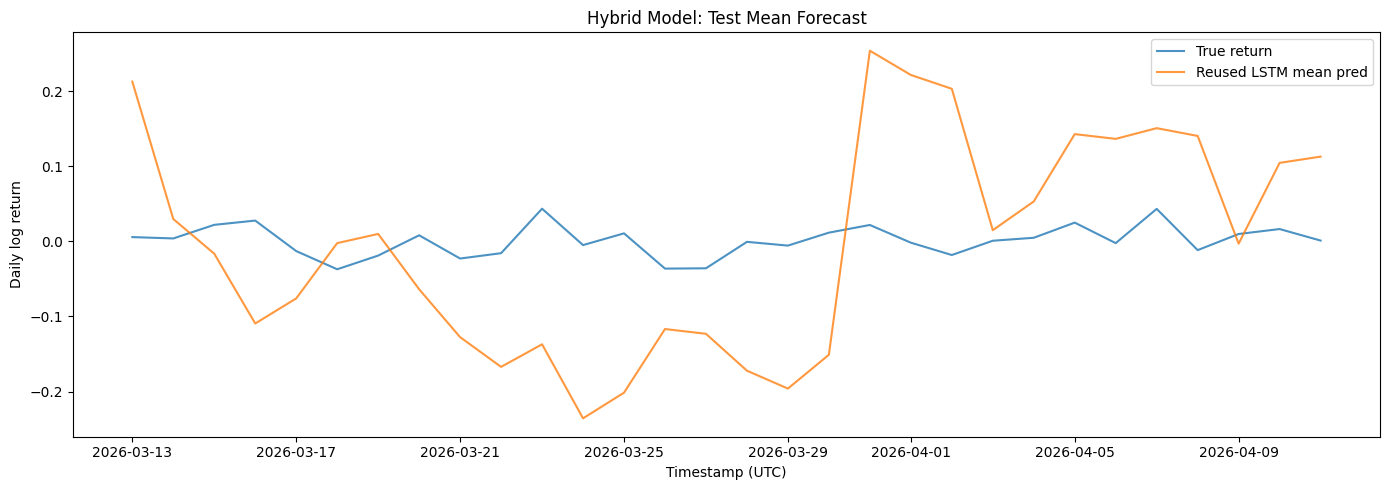

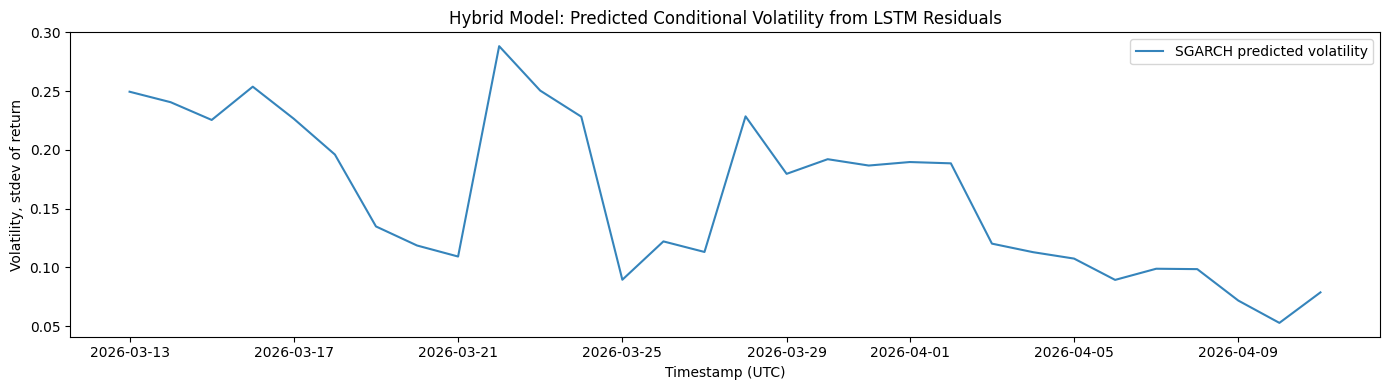

{'run_config_signature': '0faa02bca6ee',
 'lstm_run_config_signature': '60536b3ea525',
 'run_dir': 'artifacts/lstm_sgarch_walk_forward/runs/0faa02bca6ee',
 'best_params': {'seq_len': 10,
  'lstm_units': 32,
  'dropout': 0.2,
  'learning_rate': 0.0002,
  'batch_size': 64},
 'validation_mean_metrics': {'mean_rmse': 0.08813388129039952,
  'mean_mae': 0.08176447656005621,
  'qlike': -3.866231486350641,
  'var_mse': 0.000190166531627906,
  'direction_acc': 0.7333333333333333},
 'test_mean_metrics': {'mean_rmse': 0.13106781383226743,
  'mean_mae': 0.12169228754937648,
  'qlike': -2.835195779482979,
  'var_mse': 0.00067581081395896,
  'direction_acc': 0.6}}

In [10]:
# Diagnostic plots: mean forecast and SGARCH volatility
plot_df = test_preds_df.copy()
plot_df[TIMESTAMP_COL] = pd.to_datetime(plot_df[TIMESTAMP_COL], utc=True)
plot_df = plot_df.sort_values(TIMESTAMP_COL)

plt.figure(figsize=(14, 5))
plt.plot(plot_df[TIMESTAMP_COL], plot_df['y_true'], label='True return', alpha=0.8)
plt.plot(plot_df[TIMESTAMP_COL], plot_df['lstm_mean_pred'], label='Reused LSTM mean pred', alpha=0.8)
plt.title('Hybrid Model: Test Mean Forecast')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Daily log return')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(plot_df[TIMESTAMP_COL], plot_df['sgarch_vol_pred'], label='SGARCH predicted volatility', alpha=0.9)
plt.title('Hybrid Model: Predicted Conditional Volatility from LSTM Residuals')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Volatility, stdev of return')
plt.legend()
plt.tight_layout()
plt.show()

summary = {'run_config_signature': RUN_CONFIG_SIGNATURE, 'lstm_run_config_signature': LSTM_RUN_CONFIG_SIGNATURE, 'run_dir': str(ARTIFACTS_DIR), 'best_params': best_params, 'validation_mean_metrics': val_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_dict(), 'test_mean_metrics': test_metrics_df[['mean_rmse', 'mean_mae', 'qlike', 'var_mse', 'direction_acc']].mean().to_dict()}
with (ARTIFACTS_DIR / 'summary.json').open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
summary
